<a href="https://colab.research.google.com/github/ankitabishttt/Neural-Network-Assignment-1/blob/main/Project_1_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas scikit-learn matplotlib

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3819 - loss: 0.9213 - val_accuracy: 0.3187 - val_loss: 0.9230
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4451 - loss: 0.8261 - val_accuracy: 0.4176 - val_loss: 0.8209
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5302 - loss: 0.7407 - val_accuracy: 0.4835 - val_loss: 0.7319
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6044 - loss: 0.6665 - val_accuracy: 0.5604 - val_loss: 0.6554
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6648 - loss: 0.6013 - val_accuracy: 0.6813 - val_loss: 0.5902
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7170 - loss: 0.5459 - val_accuracy: 0.7363 - val_loss: 0.5363
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7445 - loss: 0.4990 - val_accuracy: 0.7692 - val_loss: 0.4915
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8049 - loss: 0.4595 - val_accuracy: 0.8132 - val_

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print(loss)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9649 - loss: 0.1378
0.13779470324516296
0.9649122953414917


In [9]:
y_pred = model.predict(X_test)

y_pred_classes = (y_pred > 0.5).astype(int)

print(y_pred_classes[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
[[1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]]


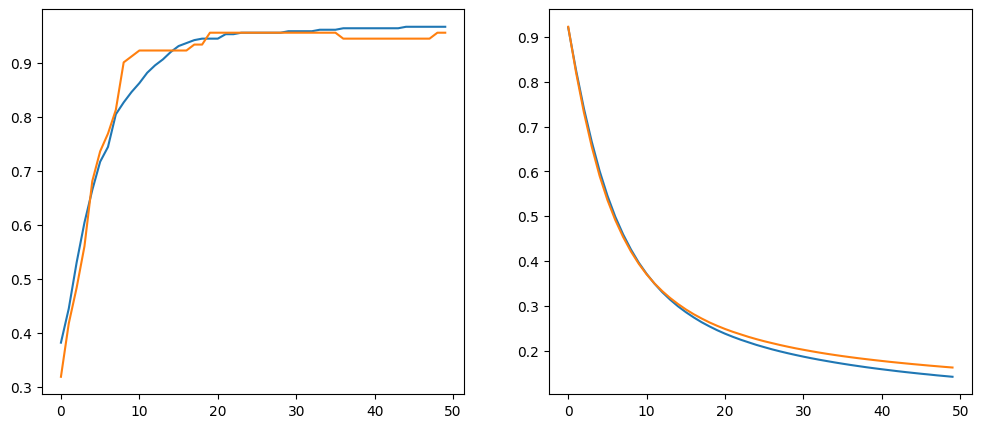

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()